# Common Test I — Multi-Class Classification
## ML4Sci GSoC 2026 | Strong Gravitational Lensing Image Classification

**Task:** Classify strong lensing images into 3 classes:
- `no` — No dark matter substructure
- `sphere` — Subhalo (CDM) substructure
- `vort` — Vortex (axion) substructure

**Dataset:** 10,000 images per class (30,000 total), single channel, 150×150 pixels, min-max normalized

**Approach:** Fine-tune EfficientNet-B0 with transfer learning

**Why EfficientNet-B0?**
- Compound scaling of depth, width and resolution together
- Only 5.3M parameters — lightweight and fast
- ImageNet pretrained weights transfer well to lensing images
- Better accuracy per parameter than ResNet or VGG
- Perfect for 150×150 single channel images at this dataset scale

**Evaluation:** ROC curve and AUC score (one-vs-rest)

## 1. Data Exploration
Explore dataset structure, image shapes, and visualize sample images.

In [1]:
import zipfile
import os

with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

DATA_DIR = '/content/dataset'
TRAIN_DIR = DATA_DIR + '/train'
VAL_DIR = DATA_DIR + '/val'
CLASS_NAMES = ['no', 'sphere', 'vort']

print("TRAIN SET:")
for c in CLASS_NAMES:
    n = len([f for f in os.listdir(f'{TRAIN_DIR}/{c}') if f.endswith('.npy')])
    print(f"  {c}: {n} images")

print("\nVAL SET:")
for c in CLASS_NAMES:
    n = len([f for f in os.listdir(f'{VAL_DIR}/{c}') if f.endswith('.npy')])
    print(f"  {c}: {n} images")

sample = np.load(f'{TRAIN_DIR}/no/1.npy')
print(f"\nImage shape: {sample.shape}")
print(f"Dtype: {sample.dtype}")
print(f"Min: {sample.min():.3f}, Max: {sample.max():.3f}")

TRAIN SET:
  no: 10000 images
  sphere: 10000 images
  vort: 10000 images

VAL SET:
  no: 2500 images
  sphere: 2500 images
  vort: 2500 images

Image shape: (1, 150, 150)
Dtype: float64
Min: 0.000, Max: 1.000


### Sample Images
Visualizing one sample from each class.

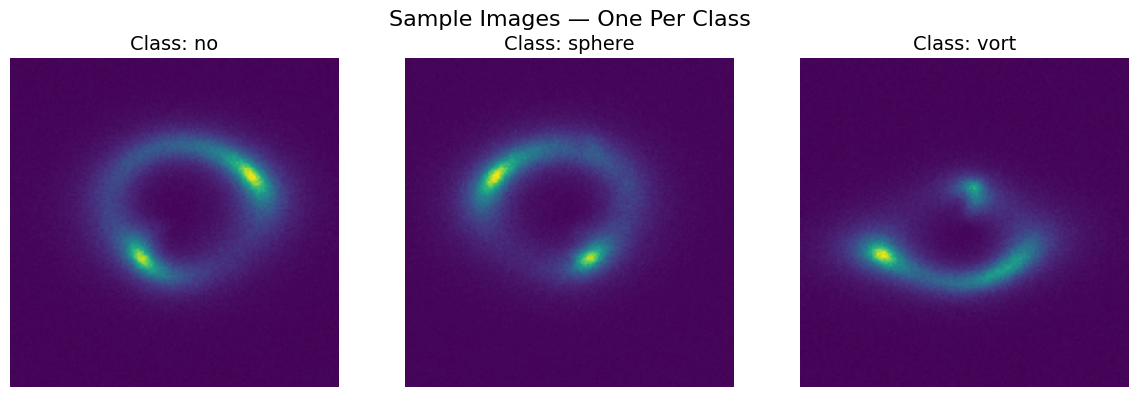

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, class_name in enumerate(CLASS_NAMES):
    img = np.load(f'{TRAIN_DIR}/{class_name}/1.npy')
    axes[i].imshow(img.squeeze(), cmap='viridis')
    axes[i].set_title(f'Class: {class_name}', fontsize=14)
    axes[i].axis('off')
plt.suptitle('Sample Images — One Per Class', fontsize=16)
plt.tight_layout()
plt.show()


## 2. Dataset & DataLoader
Custom PyTorch Dataset to load .npy lensing images and convert them to tensors.
Images are single channel (1, 150, 150) — we repeat the channel 3 times to support
pretrained models that expect RGB input.

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

class LensingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.samples = []
        for class_name in CLASS_NAMES:
            class_dir = os.path.join(data_dir, class_name)
            label = CLASS_TO_IDX[class_name]
            for fname in os.listdir(class_dir):
                if fname.endswith('.npy'):
                    self.samples.append((os.path.join(class_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path).astype(np.float32)
        img = np.squeeze(img)
        img = np.stack([img, img, img], axis=0)
        img = torch.tensor(img)
        if self.transform:
            img = self.transform(img)
        return img, label

    def __init__(self, data_dir, transform=None):
        self.transform = transform
        self.samples = []
        for class_name in CLASS_NAMES:
            class_dir = os.path.join(data_dir, class_name)
            label = CLASS_TO_IDX[class_name]
            for fname in os.listdir(class_dir):
                if fname.endswith('.npy'):
                    self.samples.append((os.path.join(class_dir, fname), label))

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = LensingDataset(TRAIN_DIR, transform=transform)
val_dataset = LensingDataset(VAL_DIR, transform=transform)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

temp_loader = DataLoader(train_dataset, batch_size=4, shuffle=False)
images, labels = next(iter(temp_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels: {labels}")

Train samples: 30000
Val samples: 7500
Batch shape: torch.Size([4, 3, 224, 224])
Labels: tensor([0, 0, 0, 0])


## 3. Train-Test Split
90:10 split on training data — 27,000 for training, 3,000 for testing.
Fixed seed (42) ensures reproducibility.

In [5]:
from torch.utils.data import random_split

train_size = int(0.9 * len(train_dataset))
test_size = len(train_dataset) - train_size

train_split, test_split = random_split(
    train_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_split, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_split, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_split)}, Test: {len(test_split)}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train: 27000, Test: 3000
Train batches: 844, Test batches: 94


## 4. Model — EfficientNet-B0
We Load pretrained EfficientNet-B0 and replace the final classifier layer with a 3 class output.

In [9]:
import torch
import torchvision.models as models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 3)
model = model.to(device)
print(model)

Using device: cuda
✅ Model on: cuda:0


## 5. Training
We train for 10 epochs using Adam optimizer and CrossEntropyLoss.

In [10]:
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")



Epoch 1/10 | Loss: 1.0189 | Acc: 45.77%
Epoch 2/10 | Loss: 0.7533 | Acc: 65.32%
Epoch 3/10 | Loss: 0.5667 | Acc: 75.60%
Epoch 4/10 | Loss: 0.4426 | Acc: 81.66%
Epoch 5/10 | Loss: 0.3568 | Acc: 85.62%
Epoch 6/10 | Loss: 0.2949 | Acc: 88.20%
Epoch 7/10 | Loss: 0.2367 | Acc: 90.74%
Epoch 8/10 | Loss: 0.1922 | Acc: 92.50%
Epoch 9/10 | Loss: 0.1551 | Acc: 94.12%
Epoch 10/10 | Loss: 0.1307 | Acc: 95.07%


## 6. Evaluation — ROC Curve & AUC Score

### What is ROC/AUC?
- **ROC (Receiver Operating Characteristic)** curve plots True Positive Rate vs False Positive Rate
- **AUC (Area Under the Curve)** measures classifier performance.


In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# binarize labels for one-vs-rest ROC
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# calculate AUC per class
print("Test Set Evaluation:")
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"  {class_name}: AUC = {roc_auc:.4f}")

Test Set Evaluation:
  no: AUC = 0.9778
  sphere: AUC = 0.9360
  vort: AUC = 0.9634


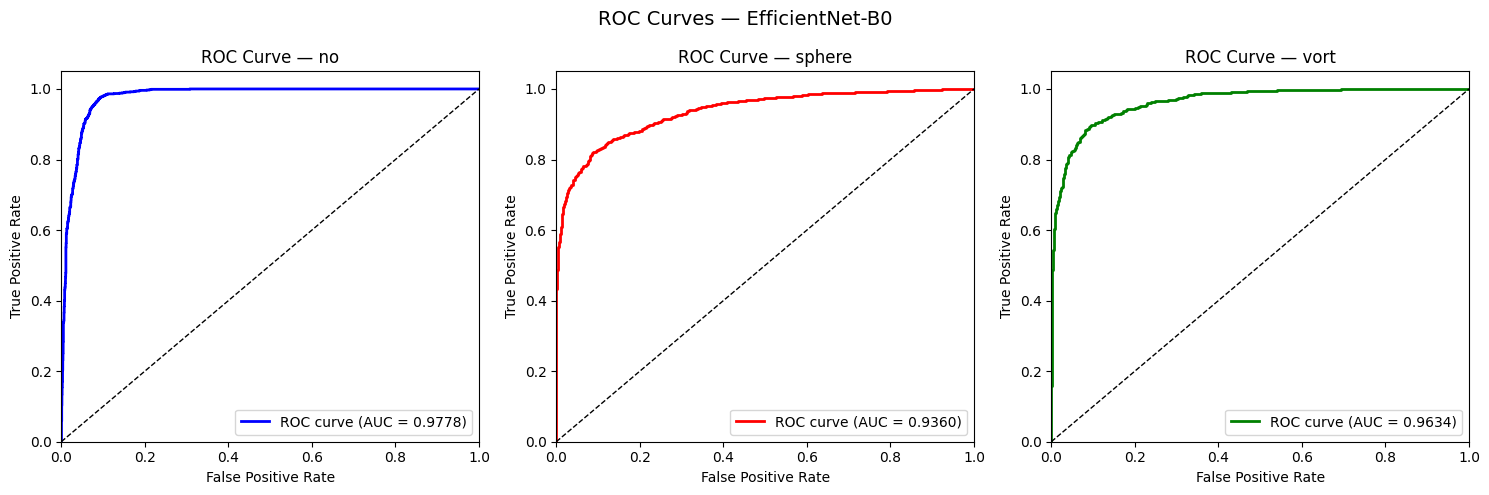

In [13]:
# plot ROC curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['blue', 'red', 'green']

for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color=color, lw=2,
                 label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve — {class_name}')
    axes[i].legend(loc="lower right")

plt.suptitle('ROC Curves — EfficientNet-B0', fontsize=14)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Results Summary

| Class | AUC Score |
|-------|-----------|
| no (no substructure) | 0.9778 |
| sphere (subhalo CDM) | 0.9360 |
| vort (axion/vortex) | 0.9634 |

### Key Observations

All AUC scores are above 0.93 — the model confidently classifies all 3 types.

**no substructure** scored highest (0.9778) because clean lensing rings
are the most visually distinct and it was easiest for the model to recognize.

**sphere** scored lowest (0.9360) because CDM subhalos create subtle
distortions that are harder to distinguish from noise.

**vort** scored in the middle (0.9634) because vortex patterns are
distinctive but still more complex than clean rings.

Training accuracy reached **95.07%** after 10 epochs with EfficientNet-B0 and ImageNet transfer learning.